In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
import os
os.chdir("D:\\Data Analytics\\PowerBI\\Customer Segmentation and Churn Analysis\\Dataset")
os.getcwd()

'D:\\Data Analytics\\PowerBI\\Customer Segmentation and Churn Analysis\\Dataset'

In [4]:
df = pd.read_csv("Bank_Churn.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [16]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [20]:
df['Geography'].unique()
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [23]:
df['CustomerId'].nunique()

10000

In [24]:
len(df)

10000

#Data Cleaning

In [25]:
df_clean = df.copy()

In [26]:
df_clean.drop('RowNumber',axis=1,inplace=True)

In [27]:
df_clean.drop('Surname', axis=1, inplace=True)

In [29]:
df_clean.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [30]:
df_clean.isna().sum()

CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [31]:
df_clean.duplicated().sum()

np.int64(0)

In [33]:
df_clean['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [34]:
df_clean['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [35]:
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
for col in binary_cols:
    print(f"\n{col}")
    print(df_clean[col].unique())


HasCrCard
[1 0]

IsActiveMember
[1 0]

Exited
[1 0]


In [37]:
df_clean['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [38]:
df_clean['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [39]:
df_clean['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [40]:
df_clean['Tenure'].value_counts().sort_index()

Tenure
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: count, dtype: int64

In [41]:
df_clean['NumOfProducts'].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [42]:
df_clean['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [43]:
df_clean['EstimatedSalary'].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [44]:
df_clean['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [45]:
df_clean['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [46]:
df_clean.to_csv("Cleaned_Bank_Churn.csv",index=False)

#Feature Engineering

In [47]:
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 29, 45, 60, float('inf')],
    labels=['<30', '30-45', '46-60', '60+']
)

In [48]:
df_clean['AgeGroup'].value_counts().sort_index()

AgeGroup
<30      1641
30-45    6248
46-60    1647
60+       464
Name: count, dtype: int64

In [49]:
df_clean['CreditScoreBand'] = pd.cut(
    df_clean['CreditScore'],
    bins=[0, 579, 669, float('inf')],
    labels=['Low', 'Medium', 'High']
)

In [50]:
df_clean['CreditScoreBand'].value_counts().sort_index()

CreditScoreBand
Low       2362
Medium    3331
High      4307
Name: count, dtype: int64

In [51]:
df_clean['TenureGroup'] = pd.cut(
    df_clean['Tenure'],
    bins=[-1, 3, 7, 10],
    labels=['New', 'Mid-term', 'Long-term']
)

In [52]:
df_clean['TenureGroup'].value_counts().sort_index()

TenureGroup
New          3505
Mid-term     3996
Long-term    2499
Name: count, dtype: int64

In [53]:
non_zero_balance_median = df_clean.loc[
    df_clean['Balance'] > 0, 
    'Balance'
].median()

non_zero_balance_median

119839.69

In [54]:
df_clean['BalanceSegment'] = np.select(
    [
        df_clean['Balance'] == 0,
        df_clean['Balance'] <= non_zero_balance_median
    ],
    [
        'Zero-balance',
        'Low-balance'
    ],
    default='High-balance'
)

In [55]:
df_clean['BalanceSegment'].value_counts()

BalanceSegment
Zero-balance    3617
Low-balance     3192
High-balance    3191
Name: count, dtype: int64

In [56]:
balance_75 = df_clean['Balance'].quantile(0.75)
salary_75 = df_clean['EstimatedSalary'].quantile(0.75)

print("Balance 75th percentile:", balance_75)
print("Salary 75th percentile:", salary_75)

Balance 75th percentile: 127644.24
Salary 75th percentile: 149388.2475


In [57]:
df_clean['CustomerValue'] = np.where(
    (df_clean['Balance'] >= balance_75) &
    (df_clean['EstimatedSalary'] >= salary_75),
    'High Value',
    'Regular Value'
)

In [58]:
df_clean['CustomerValue'].value_counts()

CustomerValue
Regular Value    9351
High Value        649
Name: count, dtype: int64

In [59]:
df_clean['EngagementStatus'] = np.where(
    df_clean['IsActiveMember'] == 1,
    'Active',
    'Inactive'
)

In [60]:
df_clean['EngagementStatus'].value_counts()

EngagementStatus
Active      5151
Inactive    4849
Name: count, dtype: int64

In [61]:
df_clean.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreBand,TenureGroup,BalanceSegment,CustomerValue,EngagementStatus
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero-balance,Regular Value,Active
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low-balance,Regular Value,Active
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,Long-term,High-balance,Regular Value,Inactive
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,High,New,Zero-balance,Regular Value,Inactive
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High-balance,Regular Value,Active


In [62]:
df_clean[
    [
        'AgeGroup',
        'CreditScoreBand',
        'TenureGroup',
        'BalanceSegment',
        'CustomerValue',
        'EngagementStatus'
    ]
].isnull().sum()

AgeGroup            0
CreditScoreBand     0
TenureGroup         0
BalanceSegment      0
CustomerValue       0
EngagementStatus    0
dtype: int64

In [63]:
df_clean.to_csv(
    'Bank_Churn_Feature_Engineered.csv',
    index=False
)

In [65]:
print(df_clean['AgeGroup'].value_counts().sort_index())

print(df_clean['CreditScoreBand'].value_counts().sort_index())

print(df_clean['TenureGroup'].value_counts().sort_index())

print(df_clean['BalanceSegment'].value_counts())

print(df_clean['CustomerValue'].value_counts())

print(df_clean['EngagementStatus'].value_counts())

AgeGroup
<30      1641
30-45    6248
46-60    1647
60+       464
Name: count, dtype: int64
CreditScoreBand
Low       2362
Medium    3331
High      4307
Name: count, dtype: int64
TenureGroup
New          3505
Mid-term     3996
Long-term    2499
Name: count, dtype: int64
BalanceSegment
Zero-balance    3617
Low-balance     3192
High-balance    3191
Name: count, dtype: int64
CustomerValue
Regular Value    9351
High Value        649
Name: count, dtype: int64
EngagementStatus
Active      5151
Inactive    4849
Name: count, dtype: int64


EDA

In [66]:
df_clean.shape

(10000, 18)

In [68]:
churn_rate = df_clean['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


In [69]:
total_customers = len(df_clean)
churned_customers = df_clean['Exited'].sum()
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print(f"Churn Rate: {churn_rate:.2f}%")

Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Churn Rate: 20.37%


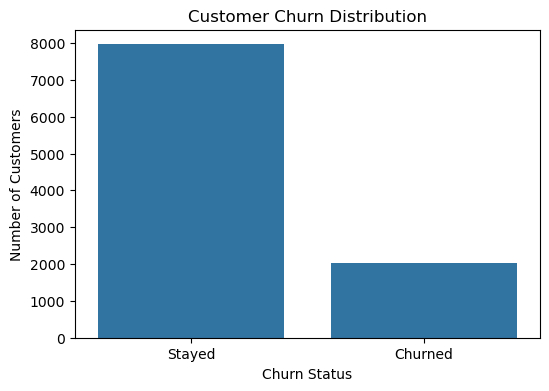

In [70]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_clean,
    x='Exited'
)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(
    [0, 1],
    ['Stayed', 'Churned']
)
plt.show()

In [71]:
churn_percent = (
    df_clean['Exited']
    .value_counts(normalize=True)
    .mul(100)
)

print(churn_percent)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


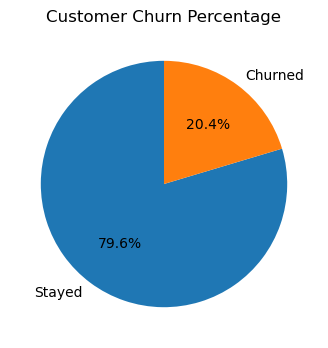

In [72]:
plt.figure(figsize=(6, 4))
plt.pie(
    churn_percent,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Churn Percentage')
plt.show()

In [73]:
geo_churn_count = (
    df_clean
    .groupby('Geography')['Exited']
    .sum()
)
geo_churn_count

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

In [74]:
geo_churn_rate = (
    df_clean
    .groupby('Geography')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
geo_churn_rate

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

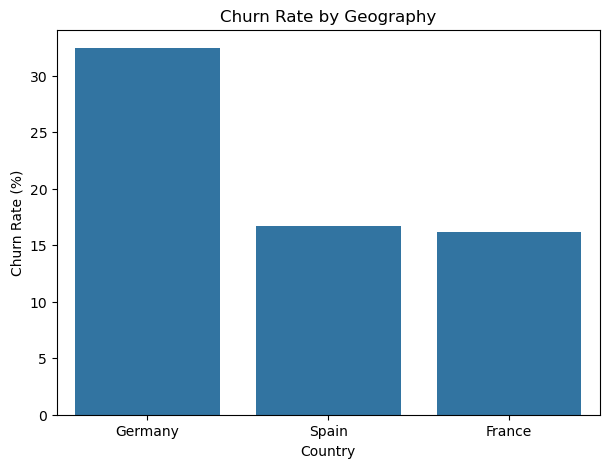

In [75]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=geo_churn_rate.index,
    y=geo_churn_rate.values
)

plt.title('Churn Rate by Geography')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.show()

In [76]:
geo_churn_count

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

In [77]:
geo_churn_rate

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

In [78]:
gender_churn_count = (
    df_clean
    .groupby('Gender')['Exited']
    .sum()
)
gender_churn_count

Gender
Female    1139
Male       898
Name: Exited, dtype: int64

In [79]:
gender_churn_rate = (
    df_clean
    .groupby('Gender')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
gender_churn_rate

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

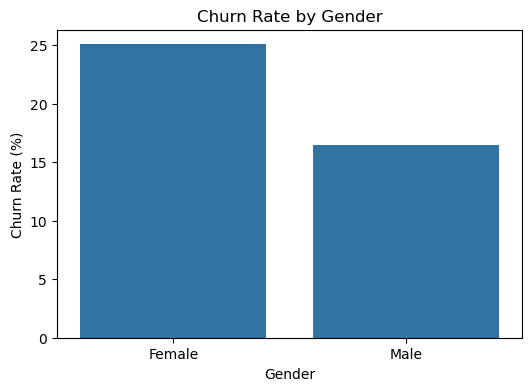

In [80]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=gender_churn_rate.index,
    y=gender_churn_rate.values
)

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.show()

In [83]:
age_churn_count = (
    df_clean
    .groupby('AgeGroup', observed=True)['Exited']
    .sum()
)
age_churn_count

AgeGroup
<30      124
30-45    956
46-60    842
60+      115
Name: Exited, dtype: int64

In [82]:
age_churn_rate = (
    df_clean
    .groupby('AgeGroup', observed=True)['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
age_churn_rate

AgeGroup
46-60    51.123254
60+      24.784483
30-45    15.300896
<30       7.556368
Name: Exited, dtype: float64

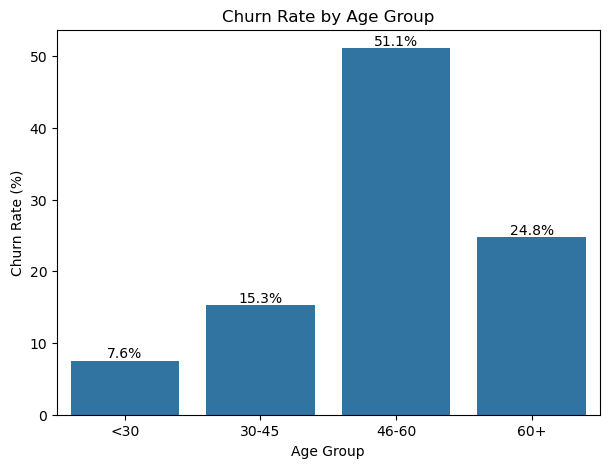

In [85]:
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=age_churn_rate.index,
    y=age_churn_rate.values
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

In [86]:
credit_churn_count = (
    df_clean
    .groupby('CreditScoreBand', observed=True)['Exited']
    .sum()
)
credit_churn_count

CreditScoreBand
Low       520
Medium    685
High      832
Name: Exited, dtype: int64

In [87]:
credit_churn_rate = (
    df_clean
    .groupby('CreditScoreBand', observed=True)['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
credit_churn_rate

CreditScoreBand
Low       22.015241
Medium    20.564395
High      19.317390
Name: Exited, dtype: float64

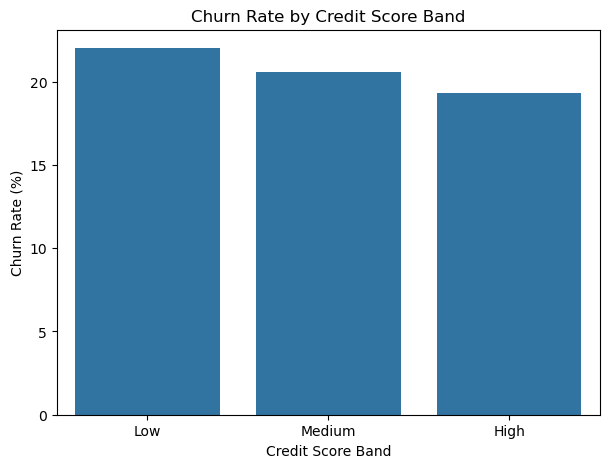

In [88]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=credit_churn_rate.index,
    y=credit_churn_rate.values
)

plt.title('Churn Rate by Credit Score Band')
plt.xlabel('Credit Score Band')
plt.ylabel('Churn Rate (%)')
plt.show()

In [89]:
tenure_churn_count = (
    df_clean
    .groupby('TenureGroup', observed=True)['Exited']
    .sum()
)
tenure_churn_count

TenureGroup
New          741
Mid-term     785
Long-term    511
Name: Exited, dtype: int64

In [90]:
tenure_churn_rate = (
    df_clean
    .groupby('TenureGroup', observed=True)['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
tenure_churn_rate

TenureGroup
New          21.141227
Long-term    20.448179
Mid-term     19.644645
Name: Exited, dtype: float64

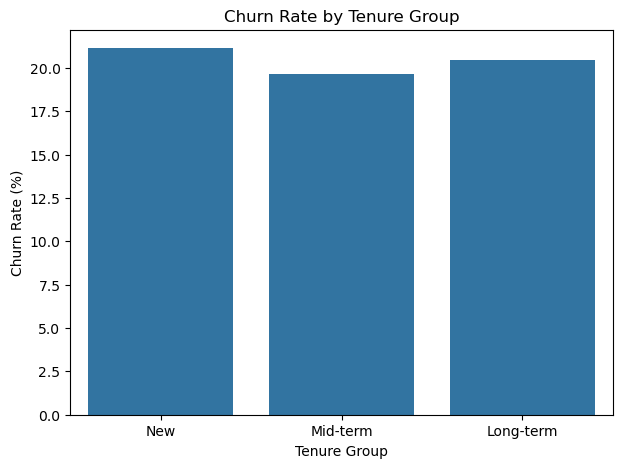

In [91]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [92]:
balance_churn_count = (
    df_clean
    .groupby('BalanceSegment')['Exited']
    .sum()
)
balance_churn_count

BalanceSegment
High-balance    771
Low-balance     766
Zero-balance    500
Name: Exited, dtype: int64

In [93]:
balance_churn_rate = (
    df_clean
    .groupby('BalanceSegment')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
balance_churn_rate

BalanceSegment
High-balance    24.161705
Low-balance     23.997494
Zero-balance    13.823611
Name: Exited, dtype: float64

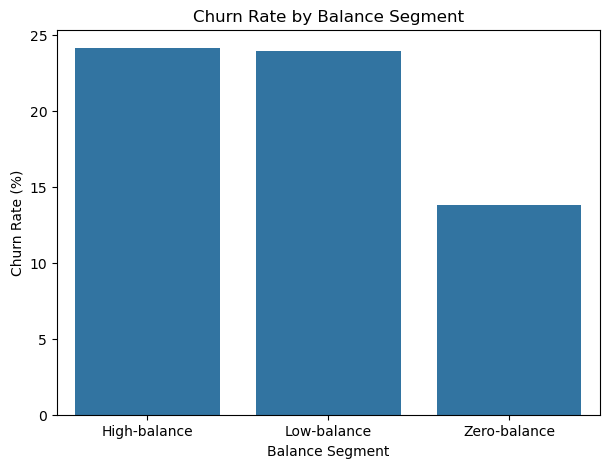

In [94]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=balance_churn_rate.index,
    y=balance_churn_rate.values
)

plt.title('Churn Rate by Balance Segment')
plt.xlabel('Balance Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#No of products

In [100]:
product_churn_count = (
    df_clean
    .groupby('NumOfProducts')['Exited']
    .sum()
)
product_churn_count

NumOfProducts
1    1409
2     348
3     220
4      60
Name: Exited, dtype: int64

In [99]:
product_churn_rate = (
    df_clean
    .groupby('NumOfProducts')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
product_churn_rate

NumOfProducts
4    100.000000
3     82.706767
1     27.714398
2      7.581699
Name: Exited, dtype: float64

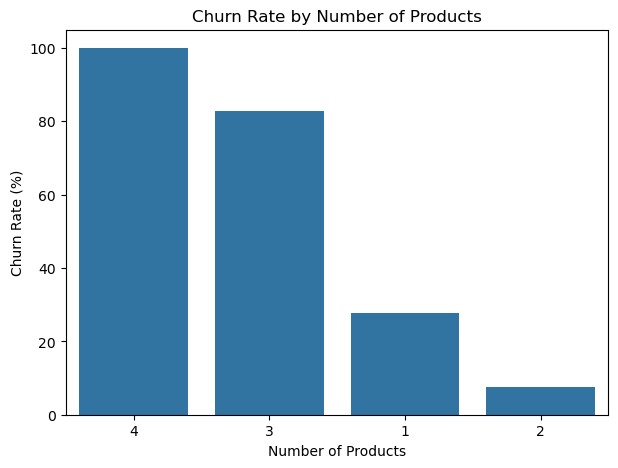

In [97]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=product_churn_rate.index.astype(str),
    y=product_churn_rate.values
)

plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#Cred card ownership

In [101]:
card_churn_count = (
    df_clean
    .groupby('HasCrCard')['Exited']
    .sum()
)
card_churn_count

HasCrCard
0     613
1    1424
Name: Exited, dtype: int64

In [102]:
card_churn_rate = (
    df_clean
    .groupby('HasCrCard')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
card_churn_rate

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

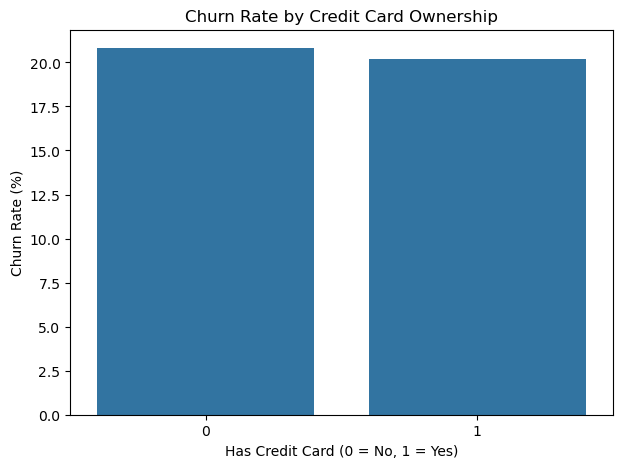

In [103]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=card_churn_rate.index.astype(str),
    y=card_churn_rate.values
)

plt.title('Churn Rate by Credit Card Ownership')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#Engagement Analysis

In [104]:
engagement_churn_count = (
    df_clean
    .groupby('EngagementStatus')['Exited']
    .sum()
)
engagement_churn_count

EngagementStatus
Active       735
Inactive    1302
Name: Exited, dtype: int64

In [105]:
engagement_churn_rate = (
    df_clean
    .groupby('EngagementStatus')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
engagement_churn_rate

EngagementStatus
Inactive    26.850897
Active      14.269074
Name: Exited, dtype: float64

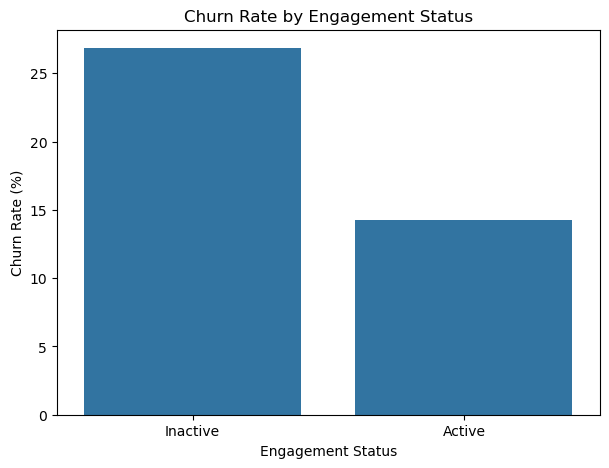

In [106]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=engagement_churn_rate.index,
    y=engagement_churn_rate.values
)

plt.title('Churn Rate by Engagement Status')
plt.xlabel('Engagement Status')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#Salary Analysis

In [107]:
salary_churn = (
    df_clean
    .groupby('Exited')['EstimatedSalary']
    .mean()
)
salary_churn

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

In [108]:
salary_churn.index = ['Stayed', 'Churned']
salary_churn

Stayed      99738.391772
Churned    101465.677531
Name: EstimatedSalary, dtype: float64

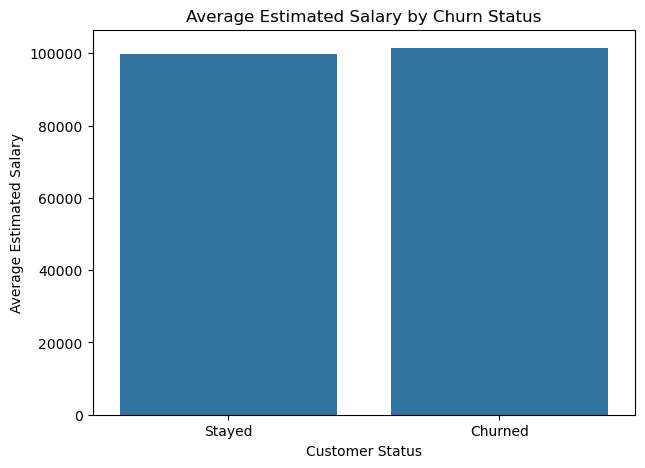

In [109]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=salary_churn.index,
    y=salary_churn.values
)

plt.title('Average Estimated Salary by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Average Estimated Salary')
plt.show()

In [ ]:
#High-Value Customer Churn Analysis

In [110]:
high_value_churn_count = (
    df_clean
    .groupby('CustomerValue')['Exited']
    .sum()
)
high_value_churn_count

CustomerValue
High Value        162
Regular Value    1875
Name: Exited, dtype: int64

In [111]:
high_value_churn_rate = (
    df_clean
    .groupby('CustomerValue')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
high_value_churn_rate

CustomerValue
High Value       24.961479
Regular Value    20.051331
Name: Exited, dtype: float64

In [112]:
balance_churn = (
    df_clean
    .groupby('Exited')['Balance']
    .mean()
)
balance_churn

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [113]:
churned_balance = df_clean.loc[
    df_clean['Exited'] == 1,
    'Balance'
].sum()

retained_balance = df_clean.loc[
    df_clean['Exited'] == 0,
    'Balance'
].sum()

print("Balance associated with churned customers:", churned_balance)
print("Balance associated with retained customers:", retained_balance)

Balance associated with churned customers: 185588094.63
Balance associated with retained customers: 579270798.25


In [115]:
total_balance = df_clean['Balance'].sum()

churned_balance_pct = (
    churned_balance / total_balance
) * 100

print(f"Total customer balance: {total_balance:,.2f}")
print(f"Churned-customer balance share: {churned_balance_pct:.2f}%")

Total customer balance: 764,858,892.88
Churned-customer balance share: 24.26%


In [116]:
high_value_churned_balance = df_clean.loc[
    (df_clean['CustomerValue'] == 'High Value') &
    (df_clean['Exited'] == 1),
    'Balance'
].sum() 

print(
    "Balance associated with churned high-value customers:",
    high_value_churned_balance
)

Balance associated with churned high-value customers: 24217707.83


In [117]:
high_value_exposure_pct = (
    high_value_churned_balance / churned_balance
) * 100

print(
    f"High-value share of churned-customer balance: "
    f"{high_value_exposure_pct:.2f}%"
)

High-value share of churned-customer balance: 13.05%


In [ ]:
#Geography × Age Analysis

In [118]:
geo_age_churn = (
    df_clean
    .groupby(['Geography', 'AgeGroup'], observed=True)['Exited']
    .mean()
    .mul(100)
    .reset_index(name='ChurnRate')
)
geo_age_churn

,Geography,AgeGroup,ChurnRate
0,France,<30,5.196305
1,France,30-45,11.868687
2,France,46-60,45.794393
3,France,60+,19.913420
4,Germany,<30,12.634409
5,Germany,30-45,25.295664
6,Germany,46-60,67.330677
7,Germany,60+,38.938053
8,Spain,<30,7.940447
9,Spain,30-45,12.516046


In [119]:
geo_age_churn.sort_values(
    'ChurnRate',
    ascending=False
)

,Geography,AgeGroup,ChurnRate
6,Germany,46-60,67.330677
2,France,46-60,45.794393
10,Spain,46-60,40.656566
7,Germany,60+,38.938053
5,Germany,30-45,25.295664
11,Spain,60+,20.833333
3,France,60+,19.913420
4,Germany,<30,12.634409
9,Spain,30-45,12.516046
1,France,30-45,11.868687


In [120]:
geo_age_count = (
    df_clean
    .groupby(
        ['Geography', 'AgeGroup'],
        observed=True
    )
    .size()
    .reset_index(name='CustomerCount')
)

geo_age_count.sort_values(
    'CustomerCount',
    ascending=False
)

,Geography,AgeGroup,CustomerCount
1,France,30-45,3168
9,Spain,30-45,1558
5,Germany,30-45,1522
0,France,<30,866
2,France,46-60,749
6,Germany,46-60,502
8,Spain,<30,403
10,Spain,46-60,396
4,Germany,<30,372
3,France,60+,231


In [121]:
age_engagement_churn = (
    df_clean
    .groupby(
        ['AgeGroup', 'EngagementStatus'],
        observed=True
    )['Exited']
    .mean()
    .mul(100)
    .reset_index(name='ChurnRate')
)

age_engagement_churn.sort_values(
    'ChurnRate',
    ascending=False
)

,AgeGroup,EngagementStatus,ChurnRate
7,60+,Inactive,82.022472
5,46-60,Inactive,68.360864
4,46-60,Active,35.348837
3,30-45,Inactive,19.312086
6,60+,Active,11.200000
2,30-45,Active,11.172459
1,<30,Inactive,9.825871
0,<30,Active,5.376344


In [122]:
age_engagement_count = (
    df_clean
    .groupby(
        ['AgeGroup', 'EngagementStatus'],
        observed=True
    )
    .size()
    .reset_index(name='CustomerCount')
)

age_engagement_count

,AgeGroup,EngagementStatus,CustomerCount
0,<30,Active,837
1,<30,Inactive,804
2,30-45,Active,3079
3,30-45,Inactive,3169
4,46-60,Active,860
5,46-60,Inactive,787
6,60+,Active,375
7,60+,Inactive,89


In [123]:
age_engagement_churn.sort_values(
    'ChurnRate',
    ascending=False
)

,AgeGroup,EngagementStatus,ChurnRate
7,60+,Inactive,82.022472
5,46-60,Inactive,68.360864
4,46-60,Active,35.348837
3,30-45,Inactive,19.312086
6,60+,Active,11.200000
2,30-45,Active,11.172459
1,<30,Inactive,9.825871
0,<30,Active,5.376344


In [ ]:
#Analysis: Germany × Age × Engagement

In [125]:
geo_age_engagement = (
    df_clean
    .groupby(
        ['Geography', 'AgeGroup', 'EngagementStatus'],
        observed=True
    )
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean')
    )
    .reset_index()
)

geo_age_engagement['ChurnRate'] = (
    geo_age_engagement['ChurnRate'] * 100
)
geo_age_engagement.sort_values(
    'ChurnRate',
    ascending=False
)

,Geography,AgeGroup,EngagementStatus,CustomerCount,ChurnedCustomers,ChurnRate
7,France,60+,Inactive,38,32,84.210526
13,Germany,46-60,Inactive,276,223,80.797101
15,Germany,60+,Inactive,31,25,80.645161
23,Spain,60+,Inactive,20,16,80.000000
21,Spain,46-60,Inactive,166,105,63.253012
5,France,46-60,Inactive,345,210,60.869565
12,Germany,46-60,Active,226,115,50.884956
4,France,46-60,Active,404,133,32.920792
11,Germany,30-45,Inactive,770,236,30.649351
20,Spain,46-60,Active,230,56,24.347826


In [ ]:
#Germany + 46–60 + Inactive + Customer Value

In [127]:
risk_value_analysis = (
    df_clean
    .groupby(
        ['Geography', 'AgeGroup', 'EngagementStatus', 'CustomerValue'],
        observed=True
    )
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_value_analysis['ChurnRate'] = (
    risk_value_analysis['ChurnRate'] * 100
)
risk_value_analysis[
    (risk_value_analysis['Geography'] == 'Germany') &
    (risk_value_analysis['AgeGroup'] == '46-60') &
    (risk_value_analysis['EngagementStatus'] == 'Inactive')
]

,Geography,AgeGroup,EngagementStatus,CustomerValue,CustomerCount,ChurnedCustomers,ChurnRate,TotalBalance
26,Germany,46-60,Inactive,High Value,32,24,75.000000,4536263.05
27,Germany,46-60,Inactive,Regular Value,244,199,81.557377,28723831.82


High-value customers within the Germany + 46–60 + inactive segment have a 75% observed churn rate, with approximately 4.54M in total balance associated with this group.

In [128]:
high_risk_high_value = df_clean[
    (df_clean['Geography'] == 'Germany') &
    (df_clean['AgeGroup'] == '46-60') &
    (df_clean['EngagementStatus'] == 'Inactive') &
    (df_clean['CustomerValue'] == 'High Value') &
    (df_clean['Exited'] == 1)
]

print("Churned high-value customers:", len(high_risk_high_value))
print("Balance associated with them:",
      high_risk_high_value['Balance'].sum())

Churned high-value customers: 24
Balance associated with them: 3385405.84


In [129]:
print(
    "Average balance:",
    high_risk_high_value['Balance'].mean()
)

Average balance: 141058.57666666666


The Germany-based 46–60 inactive high-value segment represents a critical retention group. Although relatively small at 32 customers, 75% of these customers have churned, with approximately 3.39 million in balances associated with the 24 churned customers.

In [130]:
high_risk_products = (
    df_clean[
        (df_clean['Geography'] == 'Germany') &
        (df_clean['AgeGroup'] == '46-60') &
        (df_clean['EngagementStatus'] == 'Inactive')
    ]
    .groupby('NumOfProducts')['Exited']
    .agg(
        CustomerCount='count',
        ChurnedCustomers='sum',
        ChurnRate='mean'
    )
    .reset_index()
)

high_risk_products['ChurnRate'] *= 100
high_risk_products

,NumOfProducts,CustomerCount,ChurnedCustomers,ChurnRate
0,1,189,167,88.359788
1,2,63,32,50.793651
2,3,18,18,100.000000
3,4,6,6,100.000000


In [131]:
df_clean.to_csv(
    'Bank_Churn_Analysis_Final.csv',
    index=False
)

In [132]:
df_clean.shape

(10000, 18)

Churn Risk Segmentation

In [133]:
df_clean['RiskScore'] = 0

df_clean['RiskScore'] += np.where(
    df_clean['Geography'] == 'Germany',
    2,
    0
)

df_clean['RiskScore'] += np.where(
    df_clean['AgeGroup'] == '46-60',
    2,
    0
)

df_clean['RiskScore'] += np.where(
    df_clean['EngagementStatus'] == 'Inactive',
    2,
    0
)

df_clean['RiskScore'] += np.where(
    df_clean['NumOfProducts'].isin([3, 4]),
    2,
    0
)

df_clean['RiskScore'] += np.where(
    df_clean['Gender'] == 'Female',
    1,
    0
)

df_clean['RiskScore'] += np.where(
    df_clean['CustomerValue'] == 'High Value',
    1,
    0
)

In [134]:
df_clean['RiskScore'].value_counts().sort_index()

RiskScore
0     1701
1     1445
2     2518
3     2066
4      922
5      896
6      219
7      187
8       31
9       14
10       1
Name: count, dtype: int64

In [135]:
df_clean['ChurnRiskSegment'] = pd.cut(
    df_clean['RiskScore'],
    bins=[-1, 2, 4, 7, 10],
    labels=[
        'Low Risk',
        'Moderate Risk',
        'High Risk',
        'Critical Risk'
    ]
)
df_clean['ChurnRiskSegment'].value_counts().sort_index()

ChurnRiskSegment
Low Risk         5664
Moderate Risk    2988
High Risk        1302
Critical Risk      46
Name: count, dtype: int64

In [136]:
risk_summary = (
    df_clean
    .groupby('ChurnRiskSegment', observed=True)
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean'),
        AverageBalance=('Balance', 'mean'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_summary['ChurnRate'] *= 100
risk_summary

,ChurnRiskSegment,CustomerCount,ChurnedCustomers,ChurnRate,AverageBalance,TotalBalance
0,Low Risk,5664,522,9.216102,65804.563233,3.727170e+08
1,Moderate Risk,2988,744,24.899598,83046.931148,2.481442e+08
2,High Risk,1302,730,56.067588,105943.827842,1.379389e+08
3,Critical Risk,46,41,89.130435,131712.013261,6.058753e+06


In [137]:
risk_value_summary = (
    df_clean
    .groupby(
        ['ChurnRiskSegment', 'CustomerValue'],
        observed=True
    )
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)
risk_value_summary

,ChurnRiskSegment,CustomerValue,CustomerCount,ChurnedCustomers,TotalBalance
0,Low Risk,High Value,174,18,2.602075e+07
1,Low Risk,Regular Value,5490,504,3.466963e+08
2,Moderate Risk,High Value,273,57,4.052312e+07
3,Moderate Risk,Regular Value,2715,687,2.076211e+08
4,High Risk,High Value,178,68,2.632891e+07
5,High Risk,Regular Value,1124,662,1.116100e+08
6,Critical Risk,High Value,24,19,3.427159e+06
7,Critical Risk,Regular Value,22,22,2.631593e+06


In [138]:
risk_churn_balance = (
    df_clean[df_clean['Exited'] == 1]
    .groupby('ChurnRiskSegment', observed=True)
    .agg(
        ChurnedCustomers=('Exited', 'size'),
        ChurnedBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_churn_balance

,ChurnRiskSegment,ChurnedCustomers,ChurnedBalance
0,Low Risk,522,41297999.25
1,Moderate Risk,744,64823823.53
2,High Risk,730,74119545.23
3,Critical Risk,41,5346726.62


In [139]:
top_risk_profiles = (
    df_clean[df_clean['Exited'] == 1]
    .groupby(
        [
            'Geography',
            'AgeGroup',
            'EngagementStatus',
            'CustomerValue'
        ],
        observed=True
    )
    .agg(
        ChurnedCustomers=('Exited', 'size'),
        ChurnedBalance=('Balance', 'sum')
    )
    .reset_index()
    .sort_values(
        'ChurnedCustomers',
        ascending=False
    )
)
top_risk_profiles.head(10)

,Geography,AgeGroup,EngagementStatus,CustomerValue,ChurnedCustomers,ChurnedBalance
7,France,30-45,Inactive,Regular Value,226,15588260.49
22,Germany,30-45,Inactive,Regular Value,219,25860517.90
26,Germany,46-60,Inactive,Regular Value,199,23472053.08
11,France,46-60,Inactive,Regular Value,194,11660842.13
20,Germany,30-45,Active,Regular Value,136,16132222.08
9,France,46-60,Active,Regular Value,128,7968504.43
5,France,30-45,Active,Regular Value,125,8120867.84
37,Spain,30-45,Inactive,Regular Value,122,7408804.40
24,Germany,46-60,Active,Regular Value,106,12559559.25
41,Spain,46-60,Inactive,Regular Value,99,6270490.38


In [140]:
df_clean.to_csv(
    'Bank_Churn_Risk_Segmented.csv',
    index=False
)

In [141]:
df_clean['RiskScore'] = 0

df_clean['RiskScore'] += np.where(df_clean['Geography'] == 'Germany', 2, 0)
df_clean['RiskScore'] += np.where(df_clean['AgeGroup'] == '46-60', 2, 0)
df_clean['RiskScore'] += np.where(df_clean['EngagementStatus'] == 'Inactive', 2, 0)
df_clean['RiskScore'] += np.where(df_clean['NumOfProducts'].isin([3, 4]), 2, 0)
df_clean['RiskScore'] += np.where(df_clean['Gender'] == 'Female', 1, 0)
df_clean['RiskScore'] += np.where(df_clean['CustomerValue'] == 'High Value', 1, 0)

In [142]:
df_clean['ChurnRiskSegment'] = pd.cut(
    df_clean['RiskScore'],
    bins=[-1, 2, 4, 7, 10],
    labels=[
        'Low Risk',
        'Moderate Risk',
        'High Risk',
        'Critical Risk'
    ]
)

In [143]:
print(df_clean['RiskScore'].value_counts().sort_index())
print()
print(df_clean['ChurnRiskSegment'].value_counts().sort_index())

RiskScore
0     1701
1     1445
2     2518
3     2066
4      922
5      896
6      219
7      187
8       31
9       14
10       1
Name: count, dtype: int64

ChurnRiskSegment
Low Risk         5664
Moderate Risk    2988
High Risk        1302
Critical Risk      46
Name: count, dtype: int64


In [144]:
risk_summary = (
    df_clean
    .groupby('ChurnRiskSegment', observed=True)
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean'),
        AverageBalance=('Balance', 'mean'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_summary['ChurnRate'] = (
    risk_summary['ChurnRate'] * 100
)

risk_summary

,ChurnRiskSegment,CustomerCount,ChurnedCustomers,ChurnRate,AverageBalance,TotalBalance
0,Low Risk,5664,522,9.216102,65804.563233,3.727170e+08
1,Moderate Risk,2988,744,24.899598,83046.931148,2.481442e+08
2,High Risk,1302,730,56.067588,105943.827842,1.379389e+08
3,Critical Risk,46,41,89.130435,131712.013261,6.058753e+06


In [145]:
score_validation = (
    df_clean
    .groupby('RiskScore')
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean')
    )
    .reset_index()
)

score_validation['ChurnRate'] = (
    score_validation['ChurnRate'] * 100
)

score_validation

,RiskScore,CustomerCount,ChurnedCustomers,ChurnRate
0,0,1701,87,5.114638
1,1,1445,118,8.166090
2,2,2518,317,12.589357
3,3,2066,403,19.506292
4,4,922,341,36.984816
5,5,896,428,47.767857
6,6,219,146,66.666667
7,7,187,156,83.422460
8,8,31,26,83.870968
9,9,14,14,100.000000


In [146]:
risk_summary

,ChurnRiskSegment,CustomerCount,ChurnedCustomers,ChurnRate,AverageBalance,TotalBalance
0,Low Risk,5664,522,9.216102,65804.563233,3.727170e+08
1,Moderate Risk,2988,744,24.899598,83046.931148,2.481442e+08
2,High Risk,1302,730,56.067588,105943.827842,1.379389e+08
3,Critical Risk,46,41,89.130435,131712.013261,6.058753e+06


In [147]:
score_validation

,RiskScore,CustomerCount,ChurnedCustomers,ChurnRate
0,0,1701,87,5.114638
1,1,1445,118,8.166090
2,2,2518,317,12.589357
3,3,2066,403,19.506292
4,4,922,341,36.984816
5,5,896,428,47.767857
6,6,219,146,66.666667
7,7,187,156,83.422460
8,8,31,26,83.870968
9,9,14,14,100.000000


In [148]:
risk_churn_balance = (
    df_clean[df_clean['Exited'] == 1]
    .groupby('ChurnRiskSegment', observed=True)
    .agg(
        ChurnedCustomers=('Exited', 'size'),
        ChurnedBalance=('Balance', 'sum'),
        AverageChurnedBalance=('Balance', 'mean')
    )
    .reset_index()
)

risk_churn_balance

,ChurnRiskSegment,ChurnedCustomers,ChurnedBalance,AverageChurnedBalance
0,Low Risk,522,41297999.25,79114.941092
1,Moderate Risk,744,64823823.53,87128.795067
2,High Risk,730,74119545.23,101533.623603
3,Critical Risk,41,5346726.62,130407.966341


In [149]:
risk_churn_balance['BalanceShare'] = (
    risk_churn_balance['ChurnedBalance']
    / churned_balance
    * 100
)

risk_churn_balance

,ChurnRiskSegment,ChurnedCustomers,ChurnedBalance,AverageChurnedBalance,BalanceShare
0,Low Risk,522,41297999.25,79114.941092,22.252505
1,Moderate Risk,744,64823823.53,87128.795067,34.928870
2,High Risk,730,74119545.23,101533.623603,39.937662
3,Critical Risk,41,5346726.62,130407.966341,2.880964


Critical Risk has the highest observed churn rate, but High Risk represents the largest financial exposure because it contains many more churned customers.

In [150]:
risk_value_summary = (
    df_clean
    .groupby(
        ['ChurnRiskSegment', 'CustomerValue'],
        observed=True
    )
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_value_summary

,ChurnRiskSegment,CustomerValue,CustomerCount,ChurnedCustomers,TotalBalance
0,Low Risk,High Value,174,18,2.602075e+07
1,Low Risk,Regular Value,5490,504,3.466963e+08
2,Moderate Risk,High Value,273,57,4.052312e+07
3,Moderate Risk,Regular Value,2715,687,2.076211e+08
4,High Risk,High Value,178,68,2.632891e+07
5,High Risk,Regular Value,1124,662,1.116100e+08
6,Critical Risk,High Value,24,19,3.427159e+06
7,Critical Risk,Regular Value,22,22,2.631593e+06


In [151]:
risk_value_summary = (
    df_clean
    .groupby(
        ['ChurnRiskSegment', 'CustomerValue'],
        observed=True
    )
    .agg(
        CustomerCount=('Exited', 'size'),
        ChurnedCustomers=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean'),
        TotalBalance=('Balance', 'sum')
    )
    .reset_index()
)

risk_value_summary['ChurnRate'] *= 100

risk_value_summary

,ChurnRiskSegment,CustomerValue,CustomerCount,ChurnedCustomers,ChurnRate,TotalBalance
0,Low Risk,High Value,174,18,10.344828,2.602075e+07
1,Low Risk,Regular Value,5490,504,9.180328,3.466963e+08
2,Moderate Risk,High Value,273,57,20.879121,4.052312e+07
3,Moderate Risk,Regular Value,2715,687,25.303867,2.076211e+08
4,High Risk,High Value,178,68,38.202247,2.632891e+07
5,High Risk,Regular Value,1124,662,58.896797,1.116100e+08
6,Critical Risk,High Value,24,19,79.166667,3.427159e+06
7,Critical Risk,Regular Value,22,22,100.000000,2.631593e+06


Insights:
Rule-based churn risk segmentation identified four customer risk groups with a clear increase in observed churn from Low Risk (9.22%) to Critical Risk (89.13%).
High Risk customers represented the largest financial exposure, accounting for 39.94% of the balance associated with churned customers. 
The analysis also identified high-priority subgroups such as inactive German customers aged 46–60, which exhibited an 80.80% observed churn rate. 
High-value customers within the Critical Risk segment showed a 79.17% churn rate, highlighting a financially important retention opportunity.